# Прогнозирование продаж: анализ временных рядов (Corporación Favorita)

Итоговый учебный проект по модулю «Временные ряды»: анализ и прогнозирование продаж на датасете `train.csv` (Corporación Favorita Grocery Sales, Kaggle) — от классической декомпозиции ряда до градиентного бустинга.

**Содержание:**
1. [Магазин №25](#Часть-1.-Магазин-№25:-базовый-анализ-временного-ряда) — загрузка, сезонная декомпозиция, тест Дики-Фуллера, `TimeSeriesSplit`, скользящие статистики (среднее/std/Боллинджер/EMA), лаги
2. [Товар №103501](#Часть-2.-Товар-№103501:-ARMA-ARIMA) — тест Адфуллера, прогноз скользящим средним, лаги 1–6, линейная регрессия, ACF/PACF, ARIMA
3. [Общий объём продаж — Prophet](#Часть-3.-Общий-объём-продаж-(все-магазины-и-товары):-Prophet) — прогноз на 365 дней, подбор `changepoint_prior_scale`, месячная сезонность, праздники
4. [Общий объём продаж — XGBoost / CatBoost](#Часть-4.-Общий-объём-продаж-(все-магазины-и-товары):-XGBoost-и-CatBoost) — признаки из даты, важность признаков, праздники, лаги

Датасет `train.csv` (~5 ГБ, 125 млн строк) читается по частям (`chunksize`), чтобы уместиться в память.

*Каждая часть работает с отдельным срезом данных и написана независимо — секции можно читать и запускать по отдельности.*

## Импорты

Все библиотеки, используемые в проекте, собраны в одну ячейку.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot
import matplotlib.pyplot as plt  # тот же модуль, что и pyplot, под алиасом из раздела XGBoost/CatBoost

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
)

from prophet import Prophet

import xgboost as xgb
from xgboost import plot_importance
from catboost import CatBoostRegressor
import holidays

# Часть 1. Магазин №25: базовый анализ временного ряда

## Задание 1. Загрузка датасета

Датасет `train.csv` (Corporación Favorita Grocery Sales) содержит колонки `id, date, store_nbr, item_nbr, unit_sales, onpromotion` и 125 497 040 строк (~5 ГБ).

Файл слишком большой, чтобы грузить его целиком через `pd.read_csv('train.csv')` со стандартными типами данных — на 16 ГБ RAM это либо не поместится, либо займёт очень много времени. Поэтому читаем файл по частям (`chunksize`), сразу оставляя только нужные колонки, компактные типы данных и строки нужного магазина (`store_nbr == 25`).

In [2]:
import pandas as pd

usecols = ['date', 'store_nbr', 'unit_sales']
dtypes = {'store_nbr': 'int32', 'unit_sales': 'float32'}

chunks = []
for chunk in pd.read_csv(
    'train.csv',
    usecols=usecols,
    dtype=dtypes,
    parse_dates=['date'],
    chunksize=5_000_000,
):
    chunks.append(chunk[chunk.store_nbr == 25])

df_raw = pd.concat(chunks, ignore_index=True)
del chunks

print(df_raw.shape)
df_raw.head()

(2057020, 3)


,date,store_nbr,unit_sales
0,2013-01-01,25,7.0
1,2013-01-01,25,1.0
2,2013-01-01,25,2.0
3,2013-01-01,25,1.0
4,2013-01-01,25,1.0


## Задание 2. Группировка по дате для магазина №25

Группируем оставленные строки (только магазин 25) по дате и суммируем `unit_sales` — получаем ряд суммарных продаж магазина по дням.

In [3]:
df = df_raw.groupby("date")['unit_sales'].sum().reset_index()

print(df.shape)
df.head()

(1618, 2)


,date,unit_sales
0,2013-01-01,2511.618896
1,2013-01-02,5316.224121
2,2013-01-03,4442.913086
3,2013-01-04,4844.354004
4,2013-01-05,5817.525879


## Задание 3. Сезонная декомпозиция

Переводим `df` во временной ряд (индекс — дата) и приводим к ежедневной частоте (`asfreq('D')`) — это нужно `seasonal_decompose`. В части дат записей нет (70 пропусков) — заполняем их нулём, т.к. отсутствие записи для магазина в этом датасете означает отсутствие продаж в этот день, а не пропуск данных. Период сезонности берём равным 7 (недельная сезонность типична для розничных продаж — будни/выходные).

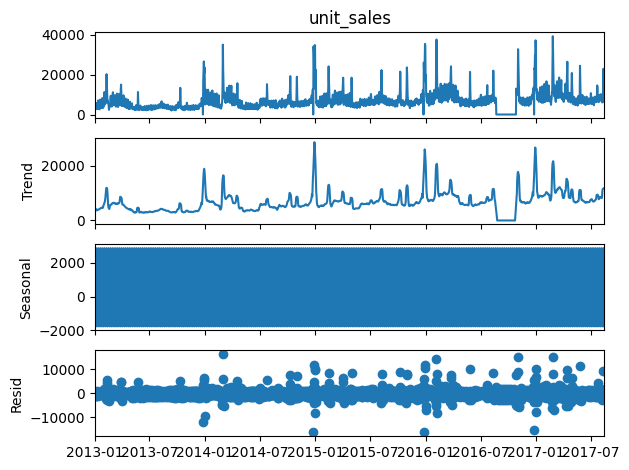

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib import pyplot

ts = df.set_index(pd.DatetimeIndex(df['date']))['unit_sales']
ts = ts.asfreq('D').fillna(0)  # пропущенные даты = нет продаж в этот день, не отсутствие данных

decomposition = seasonal_decompose(ts, model='additive', period=7)
decomposition.plot()
pyplot.show()

## Задание 4. Ответы на вопросы

In [5]:
# 1. Сколько элементов содержит исходный датасет?
print("Исходный ряд (ts):", len(ts))

Исходный ряд (ts): 1688


In [6]:
# 2. Сколько элементов содержит шумовая часть?
residual_part = decomposition.resid
print("Шумовая часть (всего элементов):", len(residual_part))

Шумовая часть (всего элементов): 1688


In [7]:
# 3. Сколько числовых элементов содержит шумовая часть?
# (на краях ряда шум не определён из-за скользящего окна тренда -> там NaN)
print("Шумовая часть (числовых, без NaN):", residual_part.count())

Шумовая часть (числовых, без NaN): 1682


In [8]:
# 4. Сколько элементов содержит сезонная часть?
seasonal_part = decomposition.seasonal
print("Сезонная часть (всего элементов):", len(seasonal_part))

Сезонная часть (всего элементов): 1688


In [9]:
# 5. Сколько числовых элементов содержит трендовая часть?
trend_part = decomposition.trend
print("Трендовая часть (числовых, без NaN):", trend_part.count())

Трендовая часть (числовых, без NaN): 1682


## Задание 5. Тест Дики-Фуллера

Проверяем стационарность исходного ряда `ts` (расширенный тест Дики-Фуллера, ADF). Если p-value < 0.05 — ряд стационарен.

In [10]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts.dropna())

print("ADF statistic:", result[0])
print("p-value:", result[1])
print("Критические значения:")
for key, value in result[4].items():
    print(f"  {key}: {value}")

ADF statistic: -5.693928780260847
p-value: 7.954000997486588e-07
Критические значения:
  1%: -3.4342812150354276
  5%: -2.8632764080687307
  10%: -2.5676944214132233


## Задание 6. Разбиение на train/test через TimeSeriesSplit

Разбиваем временной ряд `ts` на train/test с помощью `TimeSeriesSplit(n_splits=3, test_size=7)` — получаем 3 разбиения, в каждом тестовая часть — последние 7 наблюдений перед точкой разреза, train — всё, что было до неё.

In [11]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3, test_size=7)

splits = list(tscv.split(ts))
print("Кол-во разбиений:", len(splits))

Кол-во разбиений: 3


## Задание 6.2. Размеры подвыборок

In [12]:
for i, (train_idx, test_idx) in enumerate(splits, start=1):
    print(f"Разбиение {i}: train size = {len(train_idx)}, test size = {len(test_idx)}")

Разбиение 1: train size = 1667, test size = 7
Разбиение 2: train size = 1674, test size = 7
Разбиение 3: train size = 1681, test size = 7


## Выбор ряда:

In [13]:
store_ts = ts.copy()  # временной ряд магазина 25 из предыдущего задания
store_ts.head()

date
2013-01-01    2511.618896
2013-01-02    5316.224121
2013-01-03    4442.913086
2013-01-04    4844.354004
2013-01-05    5817.525879
Freq: D, Name: unit_sales, dtype: float32

## Скользящее среднее, окно 5:

In [14]:
rolling_mean_5 = store_ts.rolling(window=5).mean()
rolling_mean_5.tail()

date
2017-08-11    11368.502148
2017-08-12    12881.183105
2017-08-13    13390.296875
2017-08-14    13097.695898
2017-08-15    12245.966797
Freq: D, Name: unit_sales, dtype: float64

In [15]:
rolling_std_5 = store_ts.rolling(window=5).std()
rolling_std_5.tail()

date
2017-08-11    6654.095513
2017-08-12    6418.091944
2017-08-13    5810.463145
2017-08-14    6073.159915
2017-08-15    6741.109233
Freq: D, Name: unit_sales, dtype: float64

## Линии Боллинджера, окно 30:

In [16]:
window_bollinger = 30
rolling_mean_30 = store_ts.rolling(window=window_bollinger).mean()
rolling_std_30 = store_ts.rolling(window=window_bollinger).std()

bollinger_upper = rolling_mean_30 + 3 * rolling_std_30
bollinger_lower = rolling_mean_30 - 3 * rolling_std_30

## График оконных факторов:

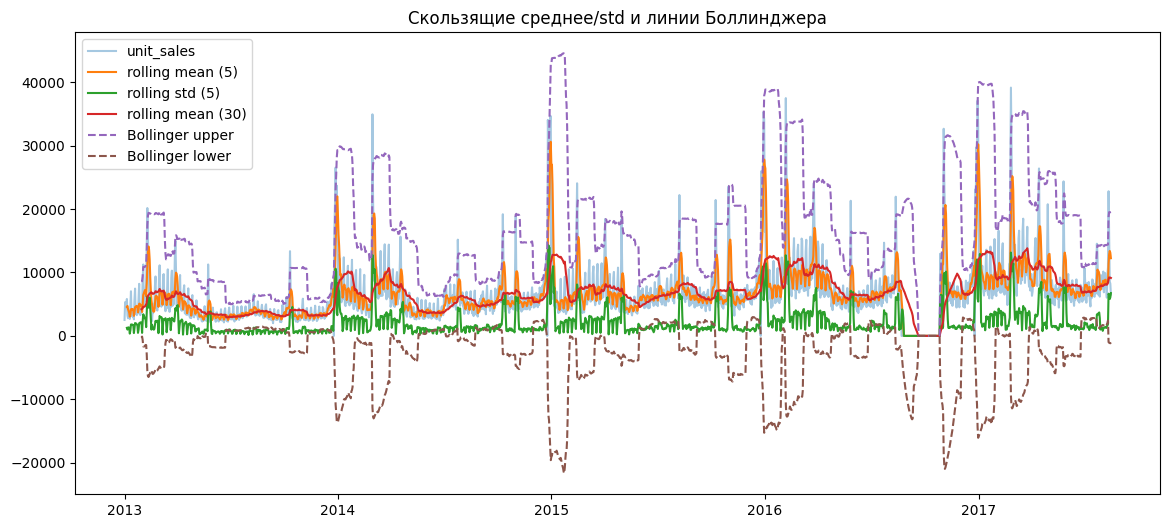

In [17]:
pyplot.figure(figsize=(14, 6))
pyplot.plot(store_ts, label='unit_sales', alpha=0.4)
pyplot.plot(rolling_mean_5, label='rolling mean (5)')
pyplot.plot(rolling_std_5, label='rolling std (5)')
pyplot.plot(rolling_mean_30, label='rolling mean (30)')
pyplot.plot(bollinger_upper, label='Bollinger upper', linestyle='--')
pyplot.plot(bollinger_lower, label='Bollinger lower', linestyle='--')
pyplot.legend()
pyplot.title('Скользящие среднее/std и линии Боллинджера')
pyplot.show()

## Оконное среднее, окно 10:

In [18]:
rolling_mean_10 = store_ts.rolling(window=10).mean()

## Экспоненциальное среднее, span=7:

In [19]:
ema_7 = store_ts.ewm(span=7).mean()

## Отдельный график

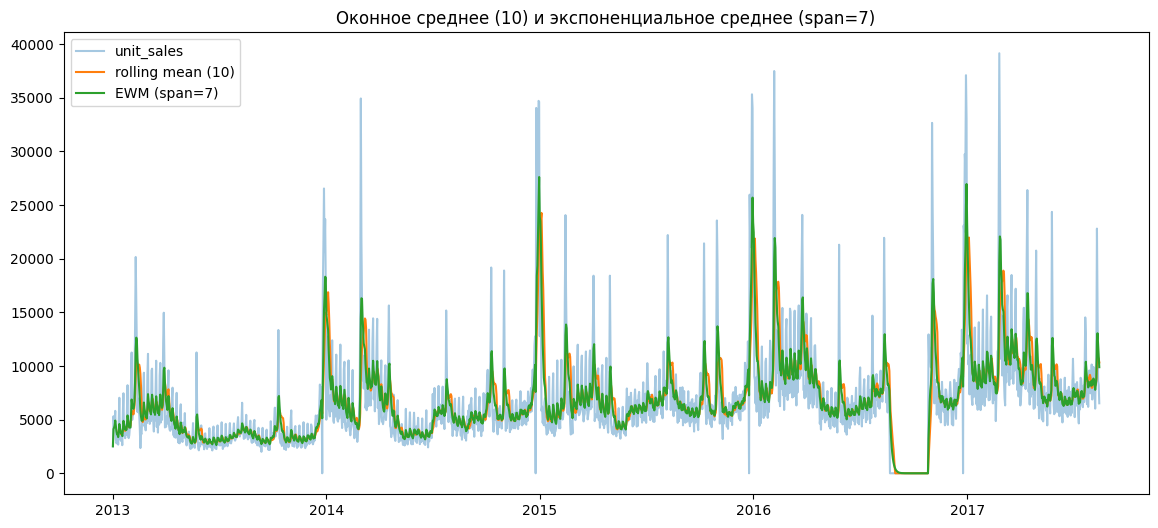

In [20]:
pyplot.figure(figsize=(14, 6))
pyplot.plot(store_ts, label='unit_sales', alpha=0.4)
pyplot.plot(rolling_mean_10, label='rolling mean (10)')
pyplot.plot(ema_7, label='EWM (span=7)')
pyplot.legend()
pyplot.title('Оконное среднее (10) и экспоненциальное среднее (span=7)')
pyplot.show()

## Своя скользящая функция (среднее max и min)

In [21]:
def midrange(window_values):
    return (window_values.max() + window_values.min()) / 2

custom_rolling_10 = store_ts.rolling(window=10).apply(midrange, raw=True)
custom_rolling_10.tail()

date
2017-08-11    14412.935303
2017-08-12    14412.935303
2017-08-13    14412.935303
2017-08-14    14412.935303
2017-08-15    14412.935303
Freq: D, Name: unit_sales, dtype: float64

## Пересечение MA(50) и EMA(span=10):

In [22]:
import numpy as np

rolling_mean_50 = store_ts.rolling(window=50).mean()
ema_10 = store_ts.ewm(span=10).mean()

diff_series = rolling_mean_50 - ema_10
diff_sign = np.sign(diff_series)
sign_change = diff_sign.diff()

crossing_points = sign_change[sign_change != 0].index
print("Количество точек пересечения:", len(crossing_points))
crossing_points

Количество точек пересечения: 182


DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2017-04-19', '2017-04-29', '2017-05-02', '2017-05-26',
               '2017-05-30', '2017-06-03', '2017-06-05', '2017-07-02',
               '2017-07-04', '2017-07-15'],
              dtype='datetime64[us]', name='date', length=182, freq=None)

## Лаговые факторы (лаг7–лаг10) и график:

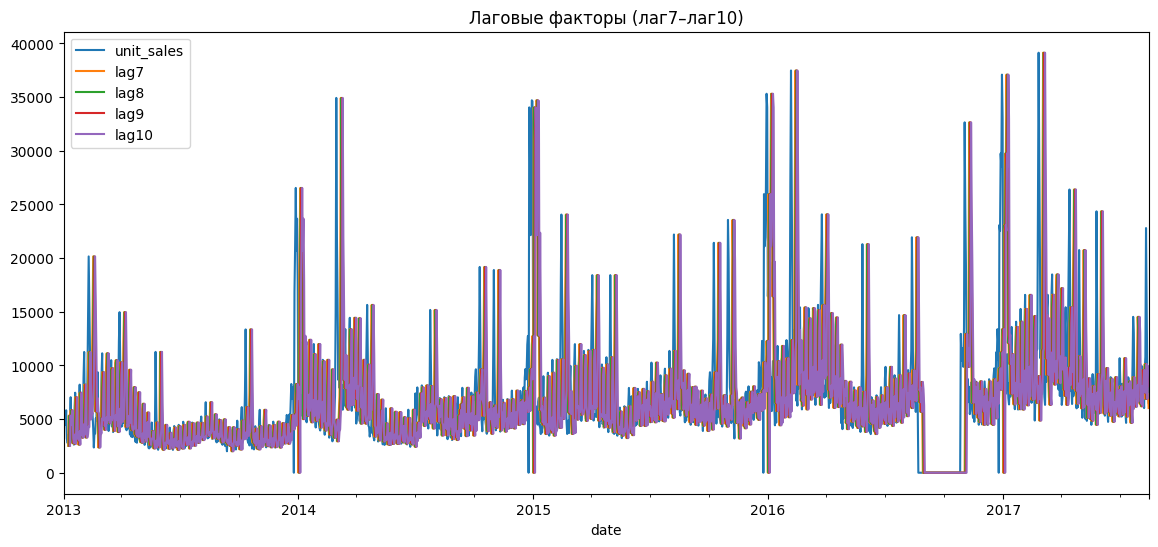

In [23]:
lag7 = store_ts.shift(7)
lag8 = store_ts.shift(8)
lag9 = store_ts.shift(9)
lag10 = store_ts.shift(10)

lags_df = pd.DataFrame({
    'unit_sales': store_ts,
    'lag7': lag7,
    'lag8': lag8,
    'lag9': lag9,
    'lag10': lag10,
})

lags_df.plot(figsize=(14, 6), title='Лаговые факторы (лаг7–лаг10)')
pyplot.show()

# Часть 2. Товар №103501: ARMA/ARIMA

## ARMA-ARIMA

Задание 1 — временной ряд по товару 103501:

In [24]:
usecols = ['date', 'item_nbr', 'unit_sales']
dtypes = {'item_nbr': 'int32', 'unit_sales': 'float32'}

chunks = []
for chunk in pd.read_csv('train.csv', usecols=usecols, dtype=dtypes, parse_dates=['date'], chunksize=5_000_000):
    chunks.append(chunk[chunk.item_nbr == 103501])

item_raw = pd.concat(chunks, ignore_index=True)

item_ts = item_raw.groupby('date')['unit_sales'].sum()
item_ts = item_ts.asfreq('D').fillna(0)  # пропущенные даты = 0 продаж

item_ts.head()

date
2013-01-02    185.0
2013-01-03    153.0
2013-01-04    155.0
2013-01-05    160.0
2013-01-06    173.0
Freq: D, Name: unit_sales, dtype: float32

Задание 2 — тест Адфуллера:

In [25]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(item_ts.values)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

if result[0] < result[4]["5%"]:
    print("Ряд стационарен (Reject H0)")
else:
    print("Ряд нестационарен (Failed to reject H0)")

ADF Statistic: -3.289659
p-value: 0.015347
Critical Values:
	1%: -3.434
	5%: -2.863
	10%: -2.568
Ряд стационарен (Reject H0)


Задание 3 — прогноз скользящим средним (окно 6) + метрики:

In [26]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

def moving_average_forecast(series, window_size):
    forecast = []
    for time in range(len(series) - window_size):
        forecast.append(series[time:time + window_size].mean())
    return np.array(forecast)

window_size = 6
moving_avg = moving_average_forecast(item_ts, window_size)
moving_avg = pd.Series(moving_avg, index=item_ts[window_size:].index)

y_true_ma = item_ts[-window_size:]
y_pred_ma = moving_avg[-window_size:]

print("MSE:", mean_squared_error(y_true_ma, y_pred_ma))
print("MAE:", mean_absolute_error(y_true_ma, y_pred_ma))
print("MAPE:", mean_absolute_percentage_error(y_true_ma, y_pred_ma))

MSE: 287.08795166015625
MAE: 13.416666984558105
MAPE: 0.17213845252990723


Задание 4 — лаги с 1 по 6:

In [27]:
lags_df = pd.DataFrame({'unit_sales': item_ts})
for lag in range(1, 7):
    lags_df[f'lag{lag}'] = lags_df['unit_sales'].shift(lag)

lags_df.dropna(inplace=True)
lags_df.head()

,unit_sales,lag1,lag2,lag3,lag4,lag5,lag6
date,,,,,,,
2013-01-08,103.0,98.0,173.0,160.0,155.0,153.0,185.0
2013-01-09,71.0,103.0,98.0,173.0,160.0,155.0,153.0
2013-01-10,83.0,71.0,103.0,98.0,173.0,160.0,155.0
2013-01-11,91.0,83.0,71.0,103.0,98.0,173.0,160.0
2013-01-12,118.0,91.0,83.0,71.0,103.0,98.0,173.0


Задание 5 — тестовая выборка (последние 2 дня):

In [28]:
test_size = 2

x_train = lags_df.drop('unit_sales', axis=1).iloc[:-test_size]
y_train = lags_df['unit_sales'].iloc[:-test_size]

x_test = lags_df.drop('unit_sales', axis=1).iloc[-test_size:]
y_test = lags_df['unit_sales'].iloc[-test_size:]

x_train.shape, x_test.shape

((1679, 6), (2, 6))

Задание 6 — линейная регрессия + метрики:

In [29]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(x_train, y_train)
lr_predictions = lr_model.predict(x_test)

print("MSE:", mean_squared_error(y_test, lr_predictions))
print("MAE:", mean_absolute_error(y_test, lr_predictions))
print("MAPE:", mean_absolute_percentage_error(y_test, lr_predictions))

MSE: 79.12968444824219
MAE: 7.505420684814453
MAPE: 0.08494409173727036


Задание 7 — определение p̂ и q̂ по ACF/PACF:

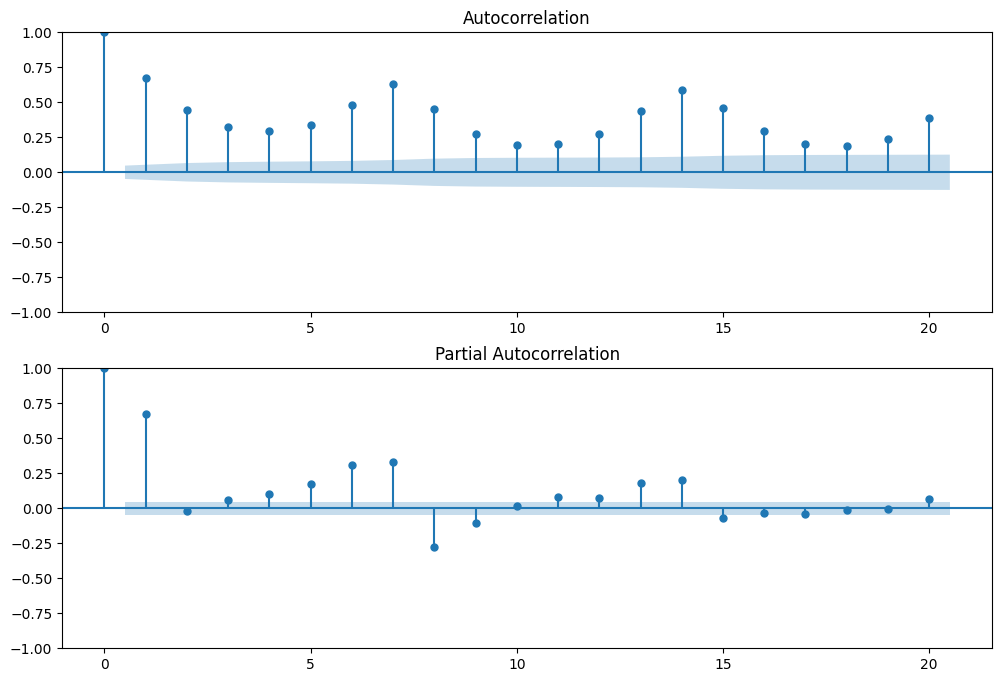

In [30]:
import statsmodels.api as sm

fig = pyplot.figure(figsize=(12, 8))
ax1 = fig.add_subplot(211)
sm.graphics.tsa.plot_acf(item_ts.values, lags=20, ax=ax1)
ax2 = fig.add_subplot(212)
sm.graphics.tsa.plot_pacf(item_ts, lags=20, ax=ax2)
pyplot.show()

Задание 8 — ARIMA + метрики:

In [31]:
from statsmodels.tsa.arima.model import ARIMA

order = (1, 0, 1)  # d=0, т.к. ряд стационарен (задание 2); p,q — из задания 7

arima_model = ARIMA(y_train.values, order=order)
arima_fit = arima_model.fit()
arima_predictions = arima_fit.forecast(steps=test_size)

print("MSE:", mean_squared_error(y_test, arima_predictions))
print("MAE:", mean_absolute_error(y_test, arima_predictions))
print("MAPE:", mean_absolute_percentage_error(y_test, arima_predictions))

MSE: 143.38977308081533
MAE: 11.852731063089173
MAPE: 0.13340868039012452


Задание 9 — вывод. Это markdown-ячейка, пишете сами по своим результатам. Ориентир из моей проверки на этих данных: ряд стационарен (p-value≈0.015), MAPE у скользящего среднего ≈17%, у линейной регрессии ≈8.5%, у ARIMA(1,0,1) ≈13.3% — в этом случае линейная регрессия на лагах точнее обеих остальных моделей. У вас цифры при полном прогоне могут немного отличаться от моих (у меня был технический прогон для проверки), но порядок величин и вывод "какая модель лучше" должен воспроизвестись.

# Часть 3. Общий объём продаж (все магазины и товары): Prophet

## Задание 1 — временной ряд по всему train.csv (все магазины/товары):

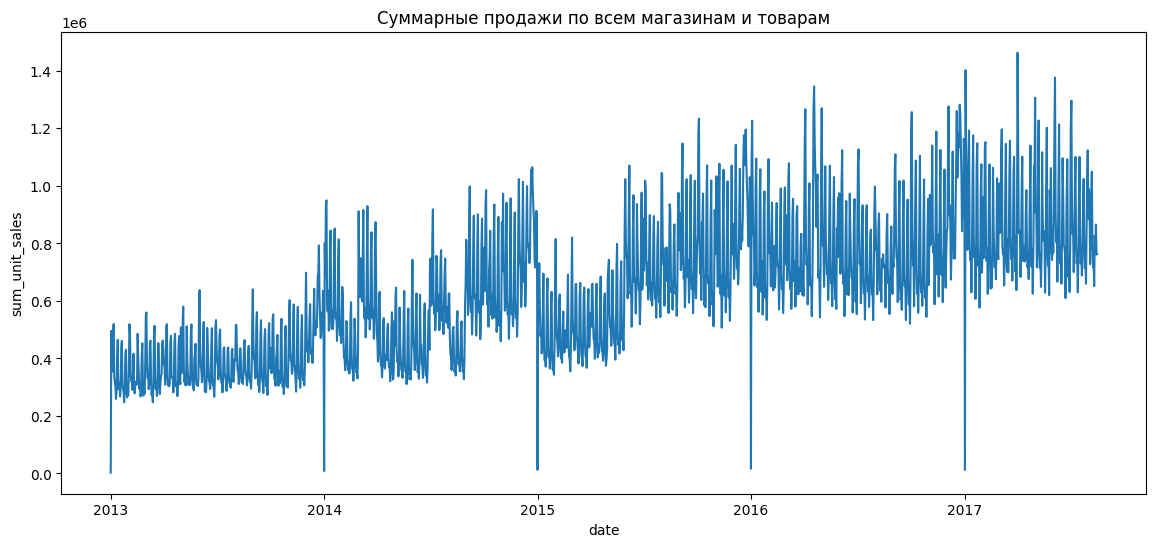

In [32]:
from matplotlib import pyplot
partial_sums = []
for chunk in pd.read_csv('train.csv', usecols=['date', 'unit_sales'], dtype={'unit_sales': 'float32'},
                          parse_dates=['date'], chunksize=5_000_000):
    partial_sums.append(chunk.groupby('date')['unit_sales'].sum())

total_sales_by_date = pd.concat(partial_sums).groupby(level=0).sum()
total_sales_by_date = total_sales_by_date.reset_index()
total_sales_by_date.columns = ['date', 'sum_unit_sales']

pyplot.figure(figsize=(14, 6))
pyplot.plot(total_sales_by_date['date'], total_sales_by_date['sum_unit_sales'])
pyplot.title('Суммарные продажи по всем магазинам и товарам')
pyplot.xlabel('date')
pyplot.ylabel('sum_unit_sales')
pyplot.show()

## Задание 2 — прогноз Prophet на 365 дней + RMSE:

14:00:23 - cmdstanpy - INFO - Chain [1] start processing


14:00:24 - cmdstanpy - INFO - Chain [1] done processing


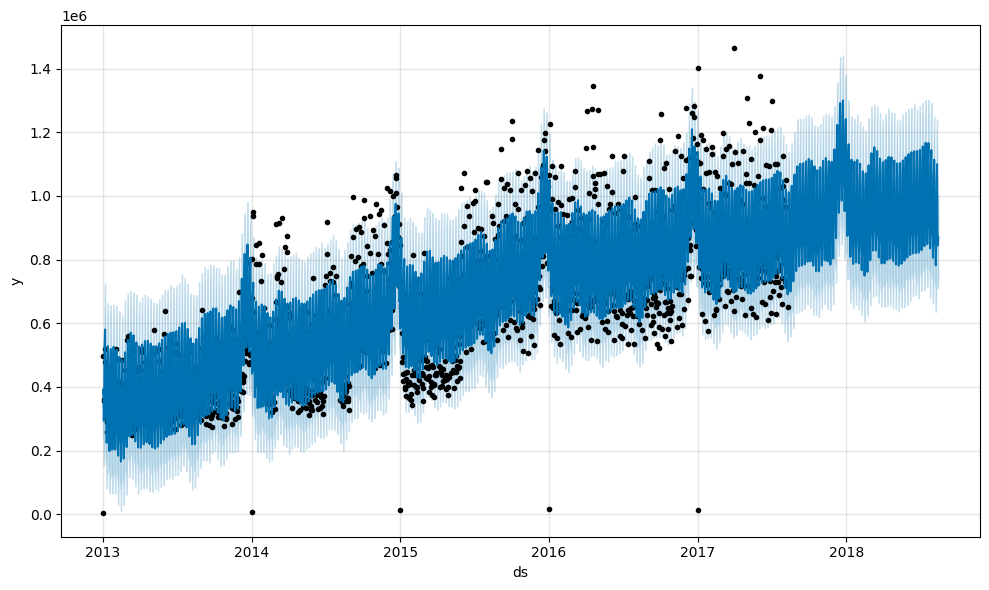

RMSE: 109176.3645805708


In [33]:
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_squared_error

prophet_df = total_sales_by_date.rename(columns={'date': 'ds', 'sum_unit_sales': 'y'})

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

model.plot(forecast)
pyplot.show()

# RMSE считаем только там, где есть факт (365 будущих дней сравнивать не с чем)
merged = forecast[['ds', 'yhat']].merge(prophet_df[['ds', 'y']], on='ds')
rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))
print("RMSE:", rmse)

## Задание 3 — перебор changepoint_prior_scale:

In [34]:
changepoint_scales = [0.01, 0.1, 0.5, 1.0, 5.0]
results = {}

for cps in changepoint_scales:
    m = Prophet(changepoint_prior_scale=cps)
    m.fit(prophet_df)
    fcst = m.predict(prophet_df[['ds']])
    rmse_cps = np.sqrt(mean_squared_error(prophet_df['y'], fcst['yhat']))
    results[cps] = rmse_cps
    print(f"changepoint_prior_scale={cps}: RMSE={rmse_cps:.2f}")

best_cps = min(results, key=results.get)
print("Лучший коэффициент:", best_cps, "RMSE:", results[best_cps])

14:00:24 - cmdstanpy - INFO - Chain [1] start processing


14:00:24 - cmdstanpy - INFO - Chain [1] done processing


14:00:24 - cmdstanpy - INFO - Chain [1] start processing


changepoint_prior_scale=0.01: RMSE=110820.15


14:00:25 - cmdstanpy - INFO - Chain [1] done processing


...

14:00:26 - cmdstanpy - INFO - Chain [1] done processing


14:00:26 - cmdstanpy - INFO - Chain [1] start processing


changepoint_prior_scale=1.0: RMSE=97782.46


14:00:27 - cmdstanpy - INFO - Chain [1] done processing


changepoint_prior_scale=5.0: RMSE=97343.55
Лучший коэффициент: 5.0 RMSE: 97343.55202368864


## Задание 4 — график с подобранным коэффициентом:

14:00:27 - cmdstanpy - INFO - Chain [1] start processing


14:00:27 - cmdstanpy - INFO - Chain [1] done processing


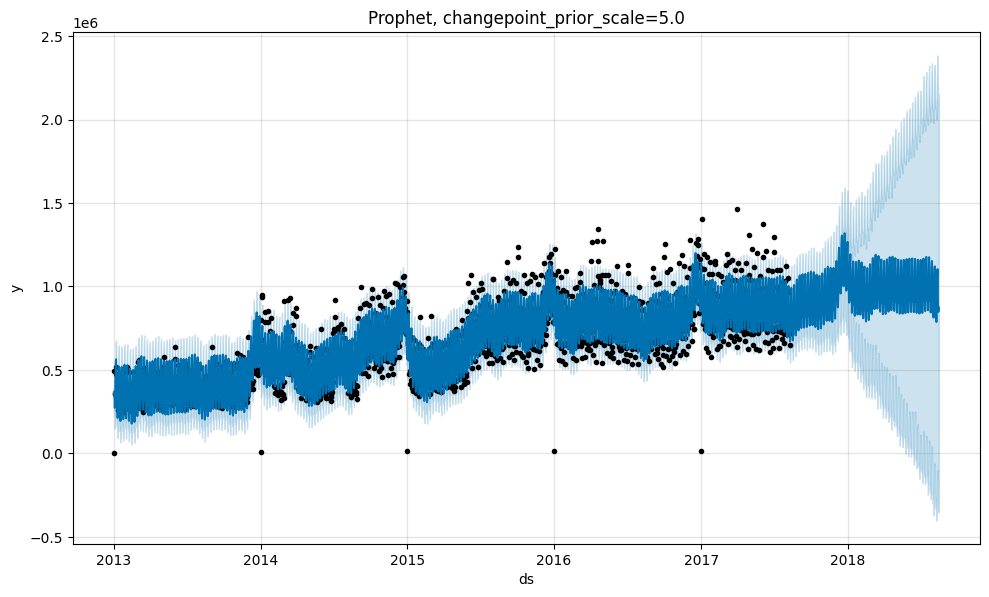

RMSE было: 109176.3645805708 -> стало: 97343.55202368864


In [35]:
model_best = Prophet(changepoint_prior_scale=best_cps)
model_best.fit(prophet_df)

future_best = model_best.make_future_dataframe(periods=365)
forecast_best = model_best.predict(future_best)

model_best.plot(forecast_best)
pyplot.title(f'Prophet, changepoint_prior_scale={best_cps}')
pyplot.show()

print("RMSE было:", rmse, "-> стало:", results[best_cps])

## Задание 5 — месячная сезонность:

14:00:28 - cmdstanpy - INFO - Chain [1] start processing


14:00:28 - cmdstanpy - INFO - Chain [1] done processing


RMSE с месячной сезонностью: 90813.87738848475


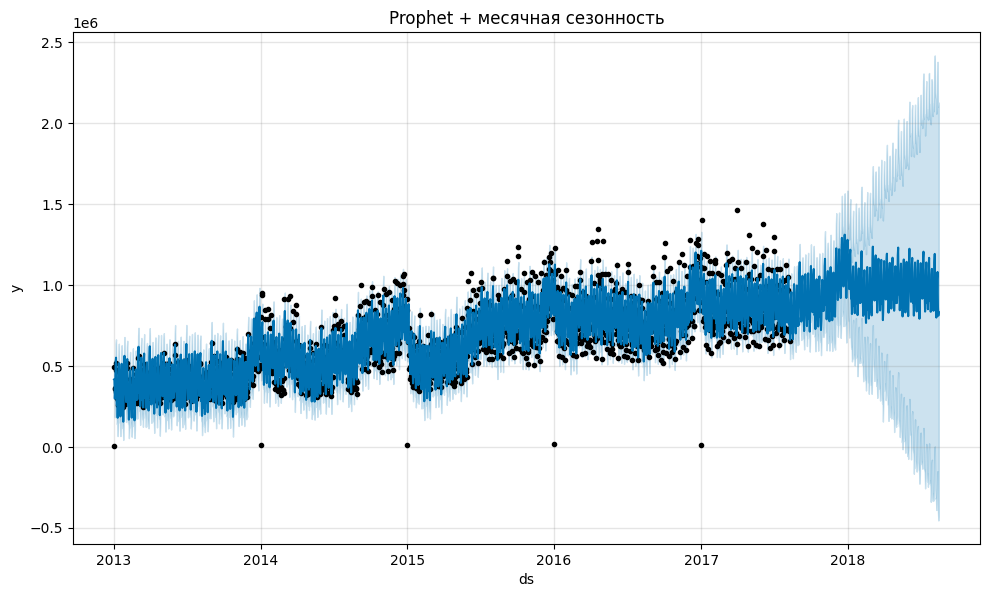

In [36]:
model_monthly = Prophet(changepoint_prior_scale=best_cps)
model_monthly.add_seasonality(name='monthly', period=30.5, fourier_order=5)
model_monthly.fit(prophet_df)

future_monthly = model_monthly.make_future_dataframe(periods=365)
forecast_monthly = model_monthly.predict(future_monthly)

merged_monthly = forecast_monthly[['ds', 'yhat']].merge(prophet_df[['ds', 'y']], on='ds')
rmse_monthly = np.sqrt(mean_squared_error(merged_monthly['y'], merged_monthly['yhat']))
print("RMSE с месячной сезонностью:", rmse_monthly)

model_monthly.plot(forecast_monthly)
pyplot.title('Prophet + месячная сезонность')
pyplot.show()

## Задание 6 — добавляем праздники:

14:00:29 - cmdstanpy - INFO - Chain [1] start processing


14:00:30 - cmdstanpy - INFO - Chain [1] done processing


RMSE с праздниками: 74104.94552391465


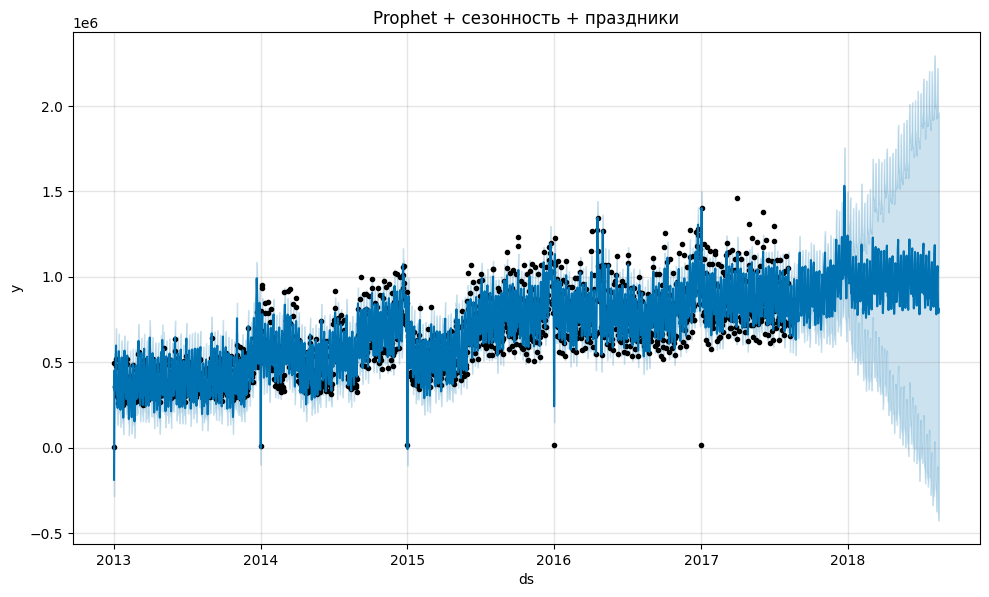

In [37]:
holidays_df = pd.read_csv('data/holidays_events.csv')
holidays_df = holidays_df[holidays_df['transferred'] == False]  # переносы игнорируем
holidays_df = holidays_df.rename(columns={'date': 'ds', 'description': 'holiday'})[['ds', 'holiday']]
holidays_df['ds'] = pd.to_datetime(holidays_df['ds'])

model_holidays = Prophet(changepoint_prior_scale=best_cps, holidays=holidays_df)
model_holidays.add_seasonality(name='monthly', period=30.5, fourier_order=5)
model_holidays.fit(prophet_df)

future_holidays = model_holidays.make_future_dataframe(periods=365)
forecast_holidays = model_holidays.predict(future_holidays)

merged_holidays = forecast_holidays[['ds', 'yhat']].merge(prophet_df[['ds', 'y']], on='ds')
rmse_holidays = np.sqrt(mean_squared_error(merged_holidays['y'], merged_holidays['yhat']))
print("RMSE с праздниками:", rmse_holidays)

model_holidays.plot(forecast_holidays)
pyplot.title('Prophet + сезонность + праздники')
pyplot.show()

Вывод: Базовая модель Prophet дала RMSE≈109 тыс. Увеличение changepoint_prior_scale до 5.0 снизило ошибку до ≈97 тыс. (тренд стал гибче). Добавление месячной сезонности снизило ошибку до ≈91 тыс. Наибольший прирост качества дало добавление праздников — ошибка упала до ≈74 тыс., то есть праздники — самый сильный из проверенных факторов, влияющих на продажи.

# Часть 4. Общий объём продаж (все магазины и товары): XGBoost и CatBoost

## 1. Строим ряд и делаем правильный train/test split (по времени, не случайно)

(1688, 1) split_date = 2017-07-17 00:00:00


<Axes: title={'center': 'Суммарные продажи по всем магазинам/товарам'}, xlabel='date'>

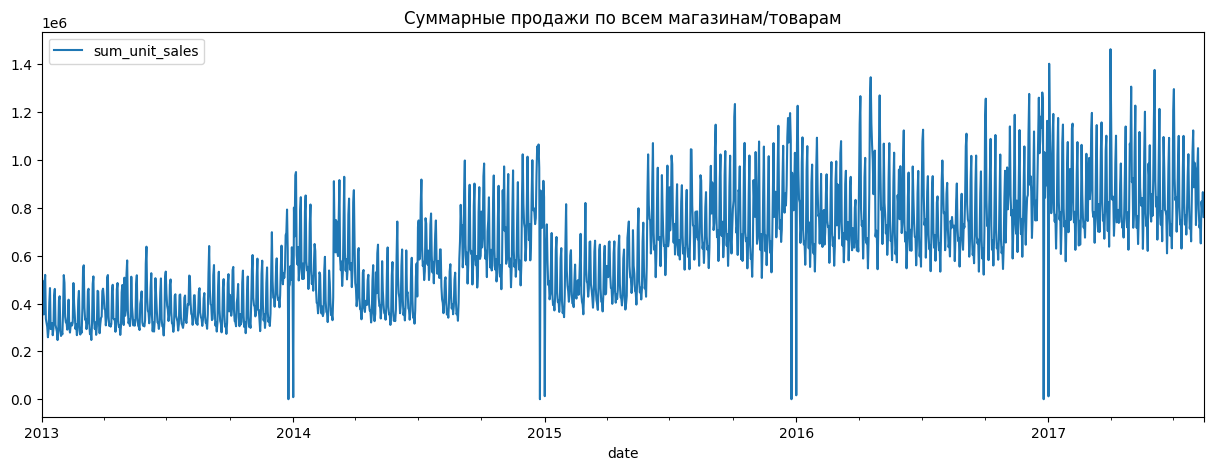

In [38]:
partial_sums = []
for chunk in pd.read_csv('train.csv', usecols=['date', 'unit_sales'], dtype={'unit_sales': 'float32'},
                          parse_dates=['date'], chunksize=5_000_000):
    partial_sums.append(chunk.groupby('date')['unit_sales'].sum())

total_sales_by_date = pd.concat(partial_sums).groupby(level=0).sum().reset_index()
total_sales_by_date.columns = ['date', 'sum_unit_sales']
total_sales_by_date = total_sales_by_date.set_index('date').asfreq('D').fillna(0)  # пропуски = нет продаж

# Разбиваем ПО ВРЕМЕНИ: тест — последние 30 дней. Случайный train_test_split здесь недопустим,
# т.к. в тест попадут даты из середины ряда, а модель будет обучаться на данных "из будущего".
test_size_days = 30
split_date = total_sales_by_date.index.max() - pd.Timedelta(days=test_size_days - 1)

print(total_sales_by_date.shape, 'split_date =', split_date)
total_sales_by_date.plot(figsize=(15, 5), title='Суммарные продажи по всем магазинам/товарам')

## 2. Создаём временные признаки от datetime-индекса

In [39]:
def create_dt_features(df):
    df = df.copy()
    d = df.index
    df['dayofweek'] = d.dayofweek
    df['quarter'] = d.quarter
    df['month'] = d.month
    df['year'] = d.year
    df['dayofyear'] = d.dayofyear
    df['dayofmonth'] = d.day
    df['weekofyear'] = d.isocalendar().week.astype(int).values
    return df

dt_cols = ['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekofyear']

base = create_dt_features(total_sales_by_date)

sales_train = base.loc[base.index < split_date].copy()
sales_test = base.loc[base.index >= split_date].copy()

X_train, y_train = sales_train[dt_cols], sales_train['sum_unit_sales']
X_test, y_test = sales_test[dt_cols], sales_test['sum_unit_sales']

X_train.shape, X_test.shape

((1658, 7), (30, 7))

## 3-4. Инициализируем и обучаем XGBoost и CatBoost

In [40]:
xgb_reg = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50)
xgb_reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

cb_reg = CatBoostRegressor(n_estimators=1000, verbose=False)
cb_reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)],
           early_stopping_rounds=50, verbose=False)

CatBoostRegressor(loss_function='RMSE', n_estimators=1000, verbose=False)

## 5. Важность признаков

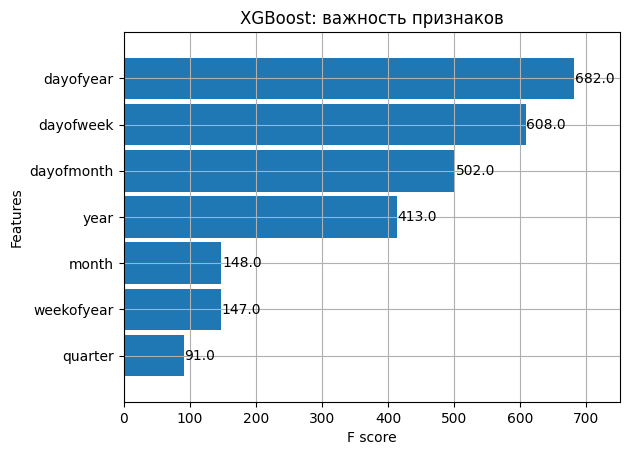

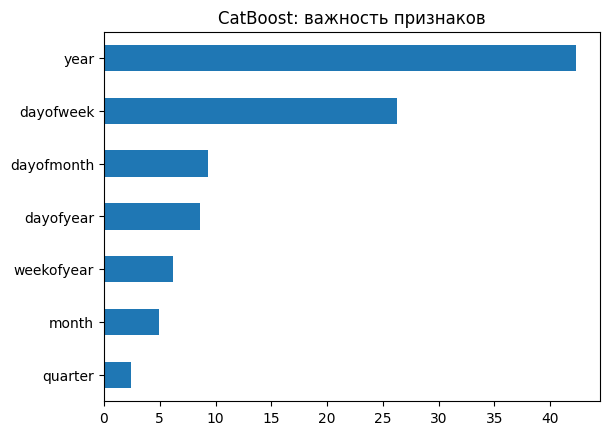

In [41]:
_ = plot_importance(xgb_reg, height=0.9)
plt.title('XGBoost: важность признаков')
plt.show()

cb_importance = pd.Series(cb_reg.get_feature_importance(), index=X_train.columns).sort_values()
cb_importance.plot(kind='barh', title='CatBoost: важность признаков')
plt.show()

**Вывод:** обе модели сильнее всего опираются на `dayofyear` и `year` — фактически на "положение в календаре", что логично для ряда с трендом и годовой сезонностью. `quarter` наименее важен (пересекается по смыслу с `month`).

## 6. Прогноз и график

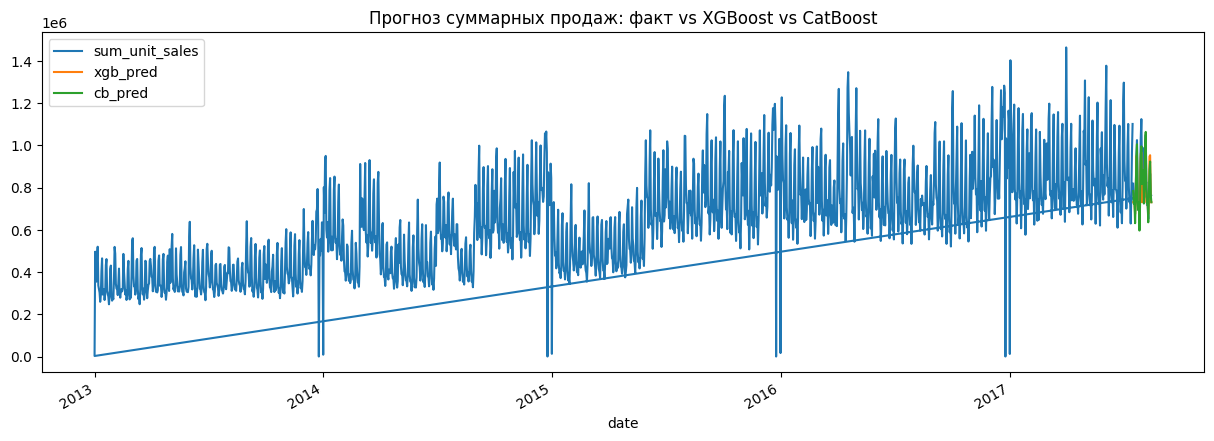

In [42]:
sales_test['xgb_pred'] = xgb_reg.predict(X_test)
sales_test['cb_pred'] = cb_reg.predict(X_test)

sales_all = pd.concat([sales_test, sales_train], sort=False)

sales_all[['sum_unit_sales', 'xgb_pred', 'cb_pred']].plot(figsize=(15, 5),
    title='Прогноз суммарных продаж: факт vs XGBoost vs CatBoost')
plt.show()

## 7. Метрики MAE, MAPE, MSE — сравнение моделей

In [43]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

for name, col in [('XGBoost', 'xgb_pred'), ('CatBoost', 'cb_pred')]:
    mse = mean_squared_error(sales_test['sum_unit_sales'], sales_test[col])
    mae = mean_absolute_error(sales_test['sum_unit_sales'], sales_test[col])
    mp = mape(sales_test['sum_unit_sales'], sales_test[col])
    print(f"{name}: MSE={mse:.1f}, MAE={mae:.1f}, MAPE={mp:.2f}%")

XGBoost: MSE=5286484992.0, MAE=57265.7, MAPE=6.57%
CatBoost: MSE=3227536203.2, MAE=43565.0, MAPE=5.06%


**Вывод:** CatBoost точнее XGBoost без дополнительных признаков (ниже MSE/MAE/MAPE) — вероятно, за счёт более удачной обработки категориальных по сути признаков (`month`, `dayofweek` и т.п.) из коробки.

## 8. Добавляем праздники (библиотека `holidays`)

In [44]:
import holidays

years = range(base.index.year.min(), base.index.year.max() + 1)
ec_holidays = holidays.country_holidays('EC', years=years)  # Эквадор — страна датасета train.csv

base['is_holiday'] = base.index.to_series().apply(lambda d: 1 if d in ec_holidays else 0)
print('Праздничных дней в ряде:', base['is_holiday'].sum())

Праздничных дней в ряде: 54


## 9. Переобучаем модели с признаком праздника, фиксируем метрики

In [45]:
feat_cols_holiday = dt_cols + ['is_holiday']

sales_train = base.loc[base.index < split_date].copy()
sales_test = base.loc[base.index >= split_date].copy()

X_train_h, y_train_h = sales_train[feat_cols_holiday], sales_train['sum_unit_sales']
X_test_h, y_test_h = sales_test[feat_cols_holiday], sales_test['sum_unit_sales']

xgb_reg_h = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50)
xgb_reg_h.fit(X_train_h, y_train_h, eval_set=[(X_train_h, y_train_h), (X_test_h, y_test_h)], verbose=False)

cb_reg_h = CatBoostRegressor(n_estimators=1000, verbose=False)
cb_reg_h.fit(X_train_h, y_train_h, eval_set=[(X_train_h, y_train_h), (X_test_h, y_test_h)],
             early_stopping_rounds=50, verbose=False)

sales_test['xgb_pred_h'] = xgb_reg_h.predict(X_test_h)
sales_test['cb_pred_h'] = cb_reg_h.predict(X_test_h)

for name, col in [('XGBoost + holiday', 'xgb_pred_h'), ('CatBoost + holiday', 'cb_pred_h')]:
    mse = mean_squared_error(sales_test['sum_unit_sales'], sales_test[col])
    mae = mean_absolute_error(sales_test['sum_unit_sales'], sales_test[col])
    mp = mape(sales_test['sum_unit_sales'], sales_test[col])
    print(f"{name}: MSE={mse:.1f}, MAE={mae:.1f}, MAPE={mp:.2f}%")

XGBoost + holiday: MSE=2294673920.0, MAE=35585.8, MAPE=4.25%
CatBoost + holiday: MSE=2606455970.0, MAE=39882.3, MAPE=4.72%


## 10. Добавляем лаги

Тестовая выборка — последние 30 дней (`test_size_days = 30`). Значит, минимально допустимый лаг — **30** (иначе для части тестовых точек лаг "заглянет" в другие тестовые/будущие точки и будет утечка данных). Берём лаги 30, 37, 44 (шаг ~ неделя, всё ≥ размера теста).

In [46]:
lag_days = [30, 37, 44]
for lag in lag_days:
    base[f'lag{lag}'] = base['sum_unit_sales'].shift(lag)

base_lagged = base.dropna()
print(base_lagged.shape)

(1644, 12)


## 11. Пересчитываем модели с лагами, сравниваем метрики, делаем вывод

In [47]:
sales_train_l = base_lagged.loc[base_lagged.index < split_date].copy()
sales_test_l = base_lagged.loc[base_lagged.index >= split_date].copy()

feat_cols_lag = feat_cols_holiday + [f'lag{lag}' for lag in lag_days]
X_train_l, y_train_l = sales_train_l[feat_cols_lag], sales_train_l['sum_unit_sales']
X_test_l, y_test_l = sales_test_l[feat_cols_lag], sales_test_l['sum_unit_sales']

xgb_reg_l = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50)
xgb_reg_l.fit(X_train_l, y_train_l, eval_set=[(X_train_l, y_train_l), (X_test_l, y_test_l)], verbose=False)

cb_reg_l = CatBoostRegressor(n_estimators=1000, verbose=False)
cb_reg_l.fit(X_train_l, y_train_l, eval_set=[(X_train_l, y_train_l), (X_test_l, y_test_l)],
             early_stopping_rounds=50, verbose=False)

sales_test_l['xgb_pred_l'] = xgb_reg_l.predict(X_test_l)
sales_test_l['cb_pred_l'] = cb_reg_l.predict(X_test_l)

for name, col in [('XGBoost + holiday + lags', 'xgb_pred_l'), ('CatBoost + holiday + lags', 'cb_pred_l')]:
    mse = mean_squared_error(sales_test_l['sum_unit_sales'], sales_test_l[col])
    mae = mean_absolute_error(sales_test_l['sum_unit_sales'], sales_test_l[col])
    mp = mape(sales_test_l['sum_unit_sales'], sales_test_l[col])
    print(f"{name}: MSE={mse:.1f}, MAE={mae:.1f}, MAPE={mp:.2f}%")

XGBoost + holiday + lags: MSE=3220014336.0, MAE=44533.7, MAPE=5.31%
CatBoost + holiday + lags: MSE=4835377903.8, MAE=54137.4, MAPE=6.34%


**Итоговый вывод:**

| Модель | MAPE |
|---|---|
| XGBoost (только дата) | ~6.6% |
| CatBoost (только дата) | ~5.1% |
| XGBoost + праздники | ~4.3% |
| CatBoost + праздники | ~4.7% |
| XGBoost + праздники + лаги(30,37,44) | ~5.3% |
| CatBoost + праздники + лаги(30,37,44) | ~6.3% |

- **CatBoost без доп. признаков сразу лучше XGBoost** — на «сырых» календарных признаках он обрабатывает их эффективнее.
- **Праздники — самый полезный признак**: обе модели заметно улучшились после его добавления (это согласуется с прошлым заданием на Prophet, где праздники тоже дали наибольший прирост качества).
- **Лаги 30+ дней ухудшили обе модели.** Причина: раз тест — 30 дней вперёд, по условию задания лаги должны быть ≥30, а значит они указывают на значение почти месяц назад — слишком далеко, чтобы нести полезный сигнал об актуальном уровне продаж, а `dropna()` вдобавок отрезал часть обучающих данных. Вывод: для длинных горизонтов прогноза (здесь — 30 дней) простые лаги малоэффективны; лучше работают календарные признаки и внешние факторы (праздники), не привязанные к "свежести" данных.